# Living-park cross-sectional analysis

## Significant digits

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from freesurfer.aparcstats2table import main as aparcstats2table
    from freesurfer.asegstats2table import main as asegstats2table
except ImportError:
    # search for freesurfer in parent directories
    for parent in Path.cwd().parents:
        if parent.name.lower() == "livingpark-numerical-variability":
            raise ImportError("Could not find freesurfer in parent directories.")
        sys.path.append(str(parent))
        try:
            from freesurfer.aparcstats2table import main as aparcstats2table
            from freesurfer.asegstats2table import main as asegstats2table

            break
        except ImportError:
            sys.path.pop()


from IPython.display import Image, display

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*ValueWarning.*")
warnings.filterwarnings("ignore", message=".*column_view.*")

force = False
anonymizer = True

root_dir = Path.cwd().parent.parent


def anondir(path: Path, prefix=root_dir) -> Path:
    """Anonymize a directory path by replacing user-specific parts with <root>."""
    if not anonymizer:
        return path
    path_str = str(path).replace(str(prefix), "<living-park>")
    return Path(path_str)


print(f"Running in root dir: {anondir(root_dir)}")
stats_dir = root_dir / "stats_QCed" / "sampled"
assert stats_dir.exists(), f"Stats directory does not exist: {anondir(stats_dir)}"
print(f"Input directory: {anondir(stats_dir)}")


output_dir = root_dir / "results" / "significant_digits"
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {anondir(output_dir)}")

figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Figures directory: {anondir(figures_dir)}")

Running in root dir: <living-park>
Input directory: <living-park>/stats_QCed/sampled
Output directory: <living-park>/results/significant_digits
Figures directory: <living-park>/results/significant_digits/figures


In [2]:
def assert_number_of_repetitions(df, hemisphere=None, repetitions=26):
    """
    Assert that each subjects/region has exactly N repetitions.
    """
    groups = ["subject_visit", "region"] + (["hemisphere"] if hemisphere else [])
    grouped = df.groupby(groups).count() == repetitions
    assert grouped.all().all(), (
        f"Not all subjects/regions have {repetitions} repetitions. {grouped[grouped == False].count()}"
    )

In [3]:
cortical_regions = [
    "bankssts",
    "caudalanteriorcingulate",
    "caudalmiddlefrontal",
    "cuneus",
    "entorhinal",
    "fusiform",
    "inferiorparietal",
    "inferiortemporal",
    "isthmuscingulate",
    "lateraloccipital",
    "lateralorbitofrontal",
    "lingual",
    "medialorbitofrontal",
    "middletemporal",
    "parahippocampal",
    "paracentral",
    "parsopercularis",
    "parsorbitalis",
    "parstriangularis",
    "pericalcarine",
    "postcentral",
    "posteriorcingulate",
    "precentral",
    "precuneus",
    "rostralanteriorcingulate",
    "rostralmiddlefrontal",
    "superiorfrontal",
    "superiorparietal",
    "superiortemporal",
    "supramarginal",
    "frontalpole",
    "temporalpole",
    "transversetemporal",
    "insula",
]

subcortical_regions = [
    "Thalamus",
    "Caudate",
    "Putamen",
    "Pallidum",
    "Hippocampus",
    "Amygdala",
    "Accumbens-area",
]

In [4]:
def save_figure(fig, filename, height=600, width=1400, scale=2, formats=None):
    """
    Save and display a plotly figure in multiple formats.

    Parameters
    ----------
    fig : plotly.graph_objects.Figure
        The plotly figure to save and display
    filename : str or Path
        The base filename (without extension) to save the figure to
    formats : list of str, optional
        List of formats to save ('html', 'pdf', 'png', 'svg')
        If None, only displays the figure

    Notes
    -----
    This function displays the figure and saves it in specified formats.
    For paper-quality figures, recommended formats are ['pdf', 'svg', 'png'].
    """
    # Always display the figure
    display(fig)

    # Save in specified formats
    if formats:
        filename = Path(filename)
        filename_anon = anondir(filename)

        # Ensure parent directory exists
        filename.parent.mkdir(parents=True, exist_ok=True)

        for fmt in formats:
            try:
                if fmt == "html":
                    fig.write_html(f"{filename}.html")
                    print(f"Saved: {filename_anon}.html")
                elif fmt == "pdf":
                    fig.write_image(
                        f"{filename}.pdf",
                        format="pdf",
                        width=width,
                        height=height,
                        scale=scale,
                    )
                    print(f"Saved: {filename_anon}.pdf")
                elif fmt == "png":
                    fig.write_image(
                        f"{filename}.png",
                        format="png",
                        width=width,
                        height=height,
                        scale=scale,
                    )
                    print(f"Saved: {filename_anon}.png")
                elif fmt == "svg":
                    fig.write_image(
                        f"{filename}.svg",
                        format="svg",
                        width=width,
                        height=height,
                        scale=scale,
                    )
                    print(f"Saved: {filename_anon}.svg")
                else:
                    print(f"Warning: Unsupported format '{fmt}' skipped")
            except Exception as e:
                print(f"Error saving {fmt} format: {e}")


def create_figure_metadata(fig, title, description, analysis_params):
    """
    Create metadata for a figure to ensure reproducibility.

    Parameters
    ----------
    fig : plotly.graph_objects.Figure
        The figure object
    title : str
        Figure title
    description : str
        Detailed description of what the figure shows
    analysis_params : dict
        Parameters used in the analysis

    Returns
    -------
    dict
        Metadata dictionary
    """
    return {
        "title": title,
        "description": description,
        "analysis_parameters": analysis_params,
        "figure_type": type(fig).__name__,
        "creation_timestamp": pd.Timestamp.now().isoformat(),
        "data_shape": getattr(fig, "data", [{}])[0].get("x", []),
        "layout_template": fig.layout.template.layout if fig.layout.template else None,
    }


In [5]:
def get_cohort_stat():
    """
    Load and process cohort statistics from CSV file.

    Returns
    -------
    pandas.DataFrame
        Processed cohort data with the following columns:
        - PATNO: Patient number
        - first_visit: Subject-session identifier for first visit
        - second_visit: Subject-session identifier for second visit
        - dx_group: Diagnosis group (PD-non-MCI or HC)
        - SEX: Subject sex
        - AGE_AT_VISIT: Age at visit

    Notes
    -----
    This function:
    1. Loads cohort data from 'cohort_stat.csv'
    2. Creates BIDS-compliant visit identifiers
    3. Provides summary statistics of the loaded cohort
    """
    df_cohort = pd.read_csv(root_dir / "cohort" / "cross-sectional_cohort_qced.csv")

    columns = [
        "PATNO",
        "visit",
        "timepoint",
        "dx_group",
        "SEX",
        "AGE_AT_VISIT",
    ]

    # Report cohort statistics
    print(
        f"Loaded cohort with {df_cohort.shape[0]} visit pairs from {df_cohort['PATNO'].nunique()} subjects"
    )
    print(
        f"PD-non-MCI: {df_cohort[df_cohort['dx_group'] == 'PD-non-MCI'].shape[0]}, "
        f"HC: {df_cohort[df_cohort['dx_group'] == 'HC'].shape[0]}"
    )

    return df_cohort[columns]


df_cohort = get_cohort_stat()


Loaded cohort with 536 visit pairs from 268 subjects
PD-non-MCI: 316, HC: 178


In [6]:
def get_metric_df(metric, hemisphere):
    """
    Get dataframe for a specific metric with enhanced performance and error handling.

    Parameters:
    -----------
    metric : str
        The name of the metric to retrieve
    hemisphere : bool
        Whether to include hemisphere information
    force : bool, default=False
        If True, regenerate the dataframe even if it exists on disk

    Returns:
    --------
    pd.DataFrame
        A dataframe containing the metric values and associated data
    """
    try:
        print(f"🔄 Creating dataframe for {metric}...")

        # Load and process data with error handling
        # Note: You may need to adjust this path to match your data location
        df = pd.read_parquet(stats_dir / f"{metric}.parquet")

        # Drop column if it exists
        if "PATNO_id" in df.columns:
            df = df.drop(columns=["PATNO_id"])
        if "rejected_images" in df.columns:
            df = df.drop(columns=["rejected_images"])
        if "image_name" in df.columns:
            df = df.drop(columns=["image_name"])
        if "path" in df.columns:
            df = df.drop(columns=["path"])
        if "input_dir" in df.columns:
            df = df.drop(columns=["input_dir"])
        if hemisphere:
            df.rename(columns={"hemi": "hemisphere"}, inplace=True)

        # Optimize repetition numbering
        print("🔄 Optimizing repetition numbering...")
        df["repetition"] = (
            df.groupby(
                ["subject_visit"] + (["hemisphere"] if hemisphere else [])
            ).cumcount()
            + 1
        )

        # Melt operation to reshape dataframe
        print(f"🔄 Reshaping data for {len(df)} records...")

        # Define ID columns based on hemisphere flag
        id_vars = [
            "repetition",
            "subject_visit",
            "subject",
            "visit",
            "dx_group",
            "PD_status",
        ] + (["hemisphere"] if hemisphere else [])
        df = df.melt(id_vars=id_vars, var_name="region", value_name=metric)

        # Clean region names
        df["region"] = df["region"].str.replace(f"_{metric}", "", regex=False)

        assert_number_of_repetitions(df, hemisphere=hemisphere)

        return df

    except Exception as e:
        print(f"❌ Error creating baseline dataframe: {e}")
        raise

In [7]:
import significantdigits as sd


def get_sd(metric, hemisphere=None, force=False):
    """
    Get significant digits for a specific metric.
    """
    num_filename = output_dir / f"{metric}_num_significant_digits.parquet"
    pop_filename = output_dir / f"{metric}_pop_significant_digits.parquet"
    if not force and num_filename.exists():
        num_sd_df = pd.read_parquet(num_filename)
    if not force and pop_filename.exists():
        pop_sd_df = pd.read_parquet(pop_filename)

    (f"🔄 Calculating significant digits for {metric}...")
    sd_df = get_metric_df(metric, hemisphere=True)
    sd_df["hemisphere"] = sd_df["hemisphere"].map({"lh": "Left", "rh": "Right"})
    sd_df[metric] = sd_df[metric].astype(np.float64)

    if force or not num_filename.exists():
        print(f"🔄 Calculating significant digits for numerical {metric}...")
        num_sd_df = (
            sd_df.groupby(["subject_visit", "region", "hemisphere"])
            .apply(
                lambda x: sd.significant_digits(
                    x[[metric]].values, reference=x[[metric]].mean(), basis=10
                )[0]
            )
            .reset_index(name="significant_digits")
        )
        num_sd_df.to_parquet(
            output_dir / f"{metric}_num_significant_digits.parquet", index=False
        )
        print(f"✅ Significant digits for numerical {metric} saved to parquet.")

    if force or not pop_filename.exists():
        print(f"🔄 Calculating significant digits for population {metric}...")
        # For population regions, we use the mean of the metric across all repetitions
        # to determine the significant digits.
        pop_sd_df = (
            sd_df.groupby(["repetition", "region", "hemisphere"])
            .apply(
                lambda x: sd.significant_digits(
                    x[[metric]].values, reference=x[[metric]].mean(), basis=10
                )[0]
            )
            .reset_index(name="significant_digits")
        )
        pop_sd_df.to_parquet(
            output_dir / f"{metric}_pop_significant_digits.parquet", index=False
        )
        print(f"✅ Significant digits for population {metric} saved to parquet.")

    return num_sd_df, pop_sd_df


def get_sd_to_plot(metric, hemisphere=None, force=False):

    num_sd_df, sd_pop_df = get_sd(metric, hemisphere=hemisphere, force=force)
    num_sd_df.rename(columns={"hemisphere": "Hemisphere"}, inplace=True)
    sd_pop_df.rename(columns={"hemisphere": "Hemisphere"}, inplace=True)

    labels = num_sd_df.region.unique()
    labels1 = labels[len(labels) // 2 :]
    labels2 = labels[: len(labels) // 2]

    sig1 = num_sd_df[num_sd_df["region"].isin(labels1)]
    sig2 = num_sd_df[num_sd_df["region"].isin(labels2)]

    subvar1 = sd_pop_df[sd_pop_df["region"].isin(labels1)]
    subvar2 = sd_pop_df[sd_pop_df["region"].isin(labels2)]

    return dict(sig1=sig1, sig2=sig2, subvar1=subvar1, subvar2=subvar2)


sd_data = {}
metrics = ["thickness", "area", "volume"]
for metric in metrics:
    sd_data[metric] = get_sd_to_plot(metric, hemisphere=True, force=force)
sd_data_copy = sd_data.copy()

🔄 Creating dataframe for thickness...
🔄 Optimizing repetition numbering...
🔄 Reshaping data for 27768 records...


🔄 Calculating significant digits for numerical thickness...


✅ Significant digits for numerical thickness saved to parquet.
🔄 Calculating significant digits for population thickness...


✅ Significant digits for population thickness saved to parquet.
🔄 Creating dataframe for area...
🔄 Optimizing repetition numbering...
🔄 Reshaping data for 27768 records...


🔄 Calculating significant digits for numerical area...


✅ Significant digits for numerical area saved to parquet.
🔄 Calculating significant digits for population area...


✅ Significant digits for population area saved to parquet.
🔄 Creating dataframe for volume...
🔄 Optimizing repetition numbering...
🔄 Reshaping data for 27768 records...


🔄 Calculating significant digits for numerical volume...


✅ Significant digits for numerical volume saved to parquet.
🔄 Calculating significant digits for population volume...


✅ Significant digits for population volume saved to parquet.


In [8]:
# Print average significant digits among regions for each metric
for metric, data in sd_data.items():
    print(f"Average significant digits for {metric}:")
    sig1 = data["sig1"]
    sig2 = data["sig2"]
    sig = pd.concat([sig1, sig2])
    sig = sig[sig["region"].isin(cortical_regions)]
    sig = (
        sig.groupby(["region", "Hemisphere"])["significant_digits"].mean().reset_index()
    )
    max_sig = sig["significant_digits"].max()
    min_sig = sig["significant_digits"].min()
    avg_sig = sig["significant_digits"].mean()
    std_sig = sig["significant_digits"].std()
    print(f" - {avg_sig:.2f} ± {std_sig:.2f}")
    print(f" - Range: {min_sig:.2f} to {max_sig:.2f}")

Average significant digits for thickness:
 - 1.62 ± 0.20
 - Range: 1.22 to 1.94
Average significant digits for area:
 - 1.34 ± 0.24
 - Range: 0.83 to 1.73
Average significant digits for volume:
 - 1.34 ± 0.23
 - Range: 0.80 to 1.73


Saved: <living-park>/results/significant_digits/figures/significant_digits.png


Saved: <living-park>/results/significant_digits/figures/significant_digits.pdf
Figure saved to: <living-park>/results/significant_digits/figures/significant_digits


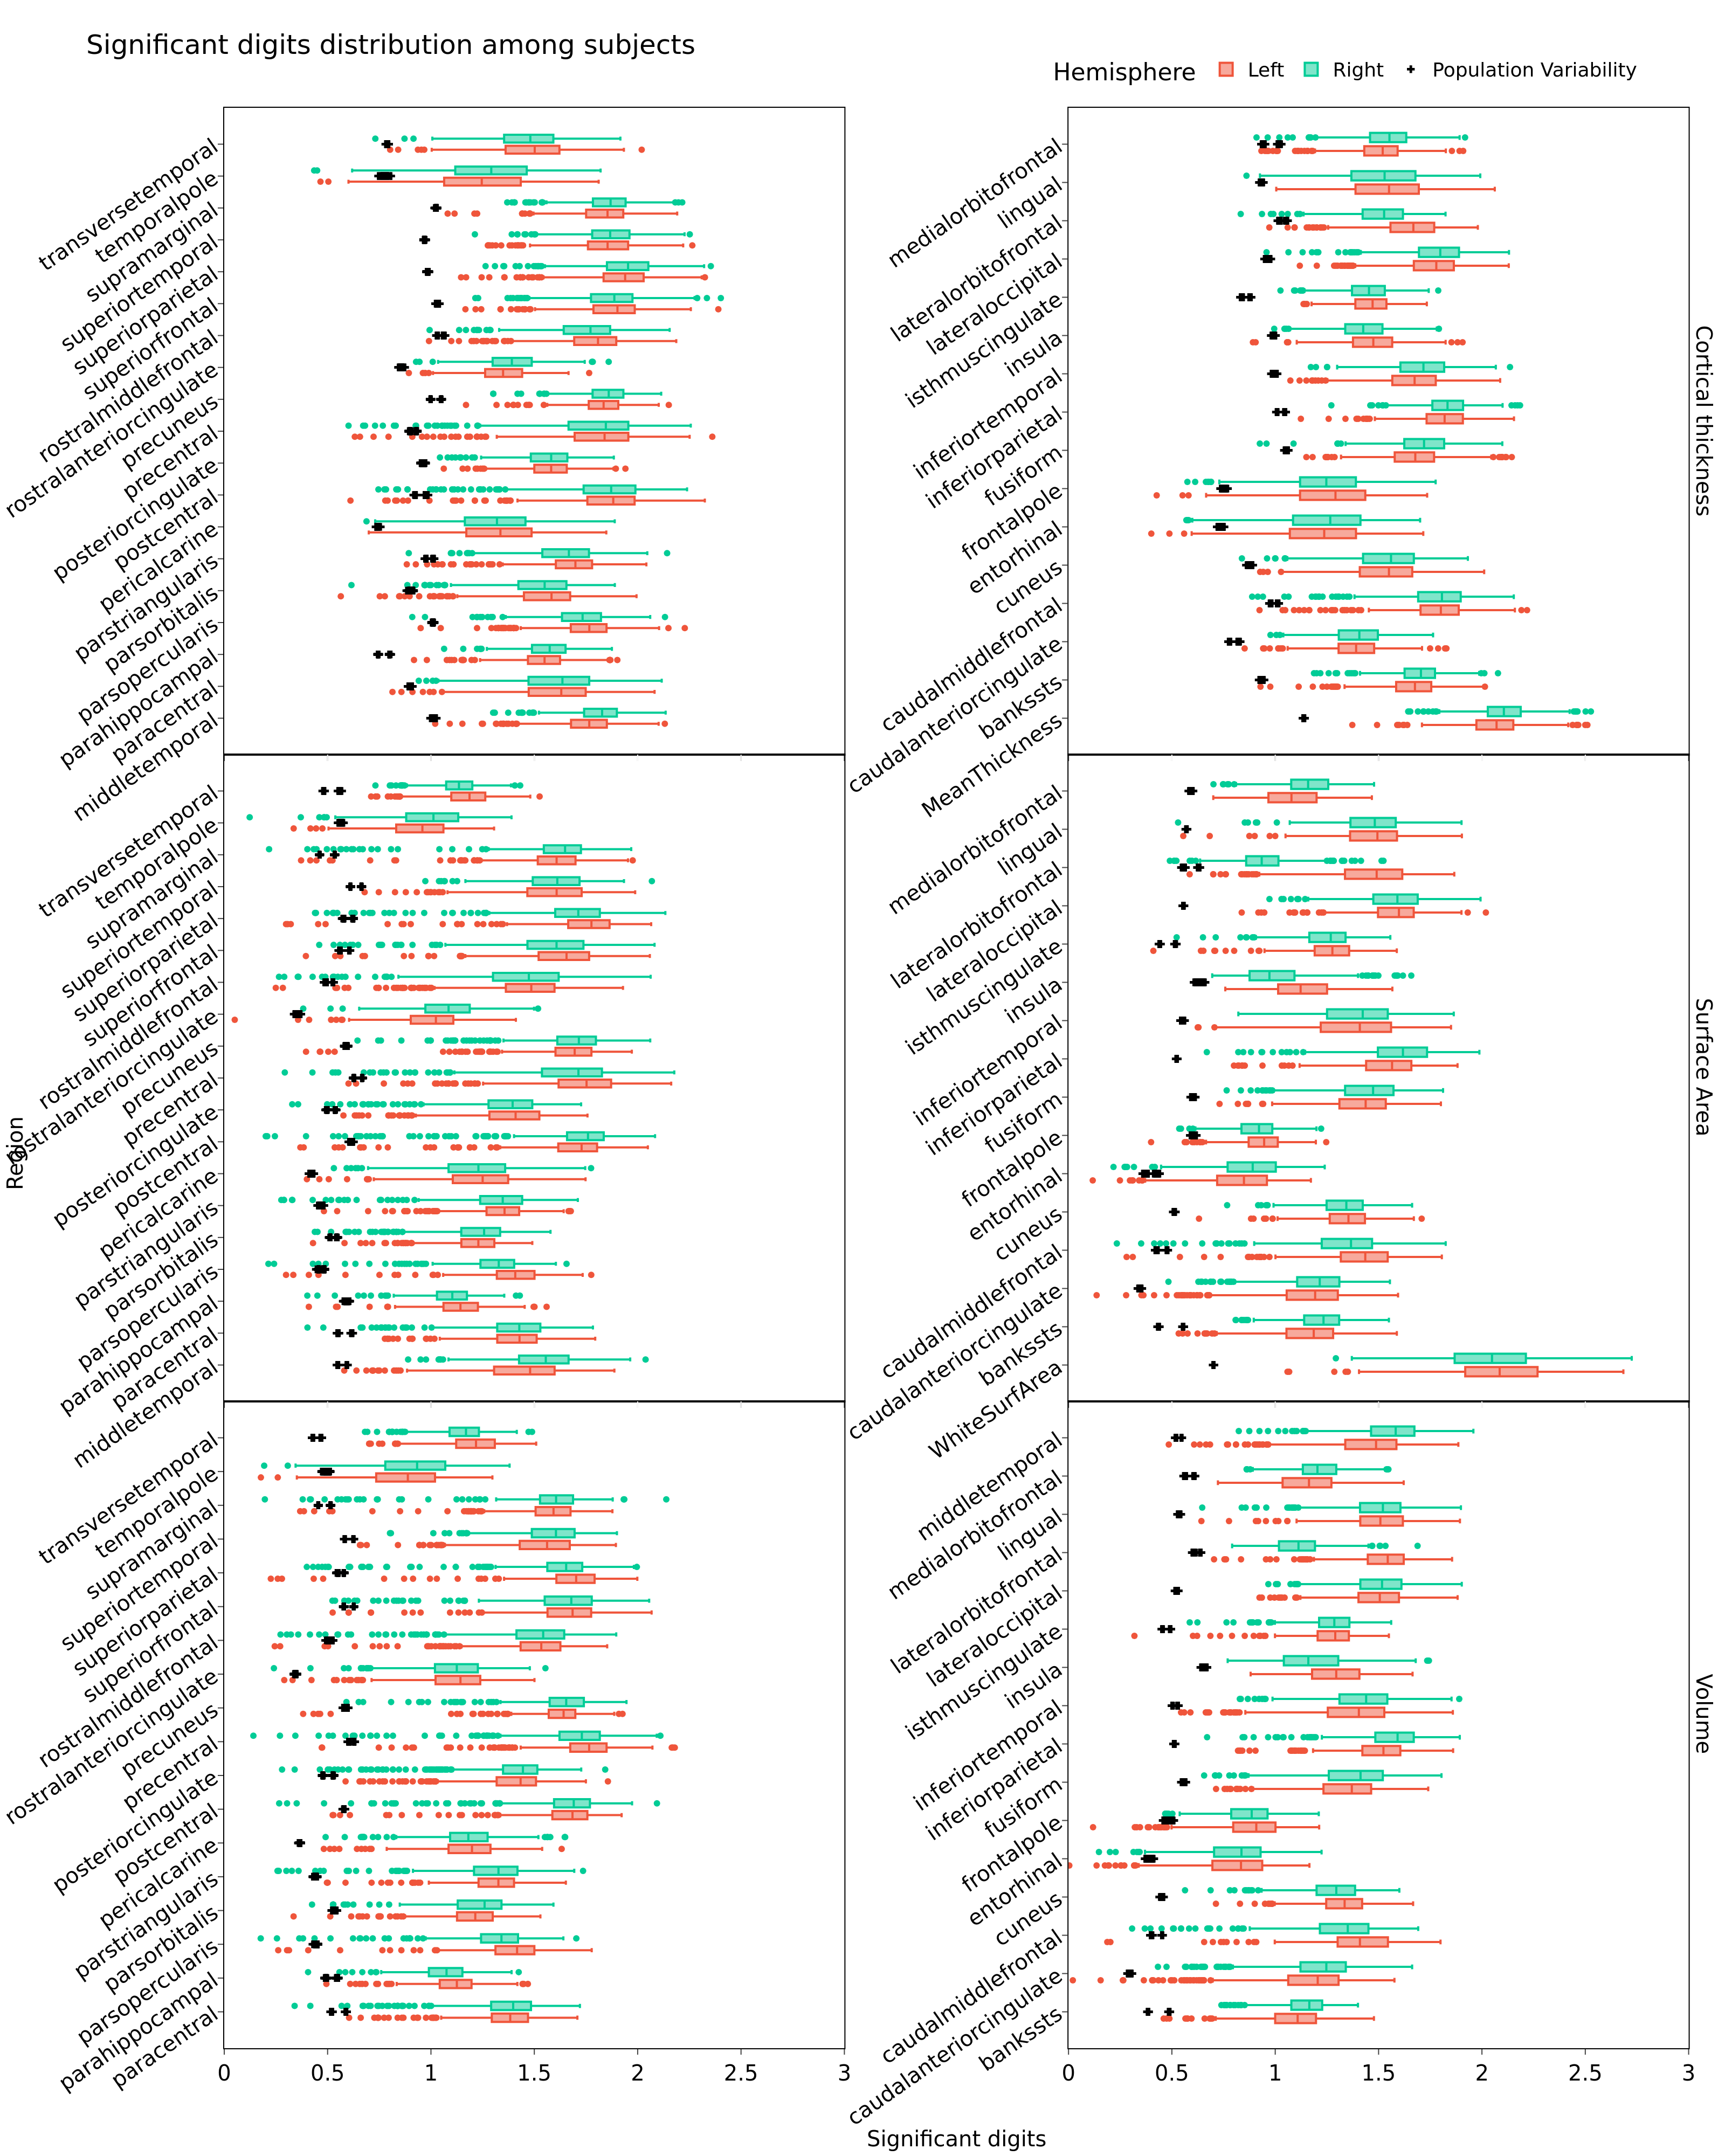

In [9]:
import plotly.colors as pc
from plotly.subplots import make_subplots
import plotly.express as px

blue = pc.qualitative.Plotly[0]
red = pc.qualitative.Plotly[1]
green = pc.qualitative.Plotly[2]

color_map = {"Left": red, "Right": green}

fig = make_subplots(
    rows=3,
    cols=2,
    horizontal_spacing=0.15,
    vertical_spacing=0,
    shared_xaxes=True,
    x_title="Significant digits",
    y_title="Region",
    row_titles=["Cortical thickness", "Surface Area", "Volume"],
)

fig.update_annotations(
    font_size=20,
    font_family="Helvetica, sans-serif",
    font_color="black",
    yshift=10,
)

metrics = ["thickness", "area", "volume"]
for i, metric in enumerate(metrics, start=1):
    data_metric = sd_data[metric]

    data_metric["sig1"] = data_metric["sig1"][
        ~data_metric["sig1"]["region"].isin(["eTIV", "BrainSegVolNotVent"])
    ]
    data_metric["sig2"] = data_metric["sig2"][
        ~data_metric["sig2"]["region"].isin(["eTIV", "BrainSegVolNotVent"])
    ]
    data_metric["subvar1"] = data_metric["subvar1"][
        ~data_metric["subvar1"]["region"].isin(["eTIV", "BrainSegVolNotVent"])
    ]
    data_metric["subvar2"] = data_metric["subvar2"][
        ~data_metric["subvar2"]["region"].isin(["eTIV", "BrainSegVolNotVent"])
    ]

    fig1 = px.box(
        data_metric["sig1"],
        x="significant_digits",
        y="region",
        color="Hemisphere",
        color_discrete_map=color_map,
    )
    fig2 = px.box(
        data_metric["sig2"],
        x="significant_digits",
        y="region",
        color="Hemisphere",
        color_discrete_map=color_map,
    )

    for data in fig1.data:
        data.showlegend = False
        fig.add_trace(data, row=i, col=1)

    for data in fig2.data:
        data.showlegend = False
        fig.add_trace(data, row=i, col=2)

    cross1 = px.scatter(
        data_metric["subvar1"],
        x="significant_digits",
        y="region",
        color="Hemisphere",
        color_discrete_map={"Left": "black", "Right": "black"},
    )
    cross2 = px.scatter(
        data_metric["subvar2"],
        x="significant_digits",
        y="region",
        color="Hemisphere",
        color_discrete_map={"Left": "black", "Right": "black"},
    )

    for data in cross1.data:
        data.showlegend = False
        data.legendgroup = "Population Variability"
        data.name = "Population Variability"
        data.marker.symbol = "cross"
        fig.add_trace(data, row=i, col=1)

    for data in cross2.data:
        data.showlegend = False
        data.marker.symbol = "cross"
        data.marker.color = "black"
        fig.add_trace(data, row=i, col=2)


fig.data[0].showlegend = True
fig.data[1].showlegend = True
fig.data[4].showlegend = True
fig.update_xaxes(range=[0, 3])

fig.update_layout(
    boxmode="group",
    title="Significant digits distribution among subjects",
    legend=dict(
        title="Hemisphere",
        tracegroupgap=0,
        orientation="h",
        yanchor="top",
        y=1.03,
        xanchor="right",
        x=0.95,
    ),
    margin=dict(l=200, r=0, b=100),
)
fig.update_layout(
    font=dict(
        family="Helvetica, sans-serif",
        size=18,
        color="black",
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
)
fig.update_annotations(font=dict(family="Helvetica, sans-serif", size=20))

fig.update_layout(
    title_font=dict(
        family="Helvetica, sans-serif",
        size=28,
        color="black",
    ),
)
fig.update_yaxes(
    title_font=dict(size=24),
    tickfont=dict(size=20),
    tickangle=-35,
    position=0.01,
    shift=-10,
)
fig.update_xaxes(
    title_font=dict(size=24),
    tickfont=dict(size=20),
)
# significant digits
fig.layout.annotations[-2].yshift = -70
# fig.layout.annotations[-2].xshift = -160
# region label
fig.layout.annotations[-1].xshift = -180
# y-labels
fig.layout.annotations[-1].yshift = -70

fig.update_xaxes(
    mirror=True, ticks="outside", showline=True, linewidth=1, linecolor="black"
)
fig.update_yaxes(
    mirror=True, ticks="outside", showline=True, linewidth=1, linecolor="black"
)

filename = figures_dir / "significant_digits"
fig.update_layout(
    width=1600, height=2000, title="Significant digits distribution among subjects"
)
save_figure(fig, filename, width=1600, height=2000, scale=2, formats=["png", "pdf"])
print(f"Figure saved to: {anondir(filename)}")
display(Image(filename.with_suffix(".png")))

In [10]:
subcortical_volume_columns_to_filter = [
    "BrainSegVolNotVent",
    "BrainSegVol",
    "CortexVol",
    "TotalGrayVol",
    "SupraTentorialVol",
    "EstimatedTotalIntraCranialVol",
    "MaskVol",
    "lhCortexVol",
    "rhCortexVol",
    "lhCerebralWhiteMatterVol",
    "rhCerebralWhiteMatterVol",
    "CerebralWhiteMatterVol",
    "SupraTentorialVolNotVent",
    "SubCortGrayVol",
    "subjects",
]


# labels order
subcortical_volume_labels = [
    "Left-Thalamus",
    "Left-Caudate",
    "Left-Putamen",
    "Left-Pallidum",
    "Left-Hippocampus",
    "Left-Amygdala",
    "Left-Accumbens-area",
    "Right-Thalamus",
    "Right-Caudate",
    "Right-Putamen",
    "Right-Pallidum",
    "Right-Hippocampus",
    "Right-Amygdala",
    "Right-Accumbens-area",
]

import significantdigits as sd


def get_sub_sd(metric, hemisphere=None, force=False):
    """
    Get significant digits for a specific metric.
    """
    num_filename = output_dir / f"{metric}_num_significant_digits.parquet"
    pop_filename = output_dir / f"{metric}_pop_significant_digits.parquet"
    if not force and num_filename.exists():
        num_sd_df = pd.read_parquet(num_filename)
    if not force and pop_filename.exists():
        pop_sd_df = pd.read_parquet(pop_filename)

    print(f"🔄 Calculating significant digits for {metric}...")
    sd_df = get_metric_df(metric, hemisphere=hemisphere)
    sd_df[metric] = sd_df[metric].astype(np.float64)
    if force or not num_filename.exists():
        num_sd_df = (
            sd_df.groupby(["subject_visit", "region"])
            .apply(
                lambda x: sd.significant_digits(
                    x[[metric]].values, reference=x[[metric]].mean(), basis=10
                )[0]
            )
            .reset_index(name="significant_digits")
        )
        num_sd_df.to_parquet(
            output_dir / f"{metric}_num_significant_digits.parquet", index=False
        )
        print(f"✅ Significant digits for numerical {metric} saved to parquet.")
    if force or not pop_filename.exists():
        print(f"🔄 Calculating significant digits for population {metric}...")
        # For population regions, we use the mean of the metric across all repetitions
        # to determine the significant digits.
        pop_sd_df = (
            sd_df.groupby(["repetition", "region"])
            .apply(
                lambda x: sd.significant_digits(
                    x[[metric]].values, reference=x[[metric]].mean(), basis=10
                )[0]
            )
            .reset_index(name="significant_digits")
        )
        pop_sd_df.to_parquet(
            output_dir / f"{metric}_pop_significant_digits.parquet", index=False
        )
        print(f"✅ Significant digits for population {metric} saved to parquet.")

    return num_sd_df, pop_sd_df


def get_sub_sd_to_plot(metric, hemisphere=None, force=force):

    num_sd_df, pop_sd_df = get_sub_sd(metric, hemisphere=hemisphere, force=force)

    labels = num_sd_df.region.unique()
    labels1 = labels[len(labels) // 2 :]
    labels2 = labels[: len(labels) // 2]

    sig1 = num_sd_df[num_sd_df["region"].isin(labels1)]
    sig2 = num_sd_df[num_sd_df["region"].isin(labels2)]

    subvar1 = pop_sd_df[pop_sd_df["region"].isin(labels1)]
    subvar2 = pop_sd_df[pop_sd_df["region"].isin(labels2)]

    return dict(sig1=sig1, sig2=sig2, subvar1=subvar1, subvar2=subvar2)


sub_sd_data = {}
metrics = ["subcortical_volume"]
for metric in metrics:
    sub_sd_data[metric] = get_sub_sd_to_plot(metric, hemisphere=None)
sub_sd_data_copy = sub_sd_data.copy()

🔄 Calculating significant digits for subcortical_volume...
🔄 Creating dataframe for subcortical_volume...
🔄 Optimizing repetition numbering...
🔄 Reshaping data for 13884 records...


/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-pack

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-pack

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-pack

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-pack

...

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-pack

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-pack

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-pack

✅ Significant digits for population subcortical_volume saved to parquet.


/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-packages/significantdigits/_significantdigits.py:283: RuntimeWarning:

invalid value encountered in divide

/home/yohan/Work/livingpark-numerical-variability/.venv/lib/python3.12/site-pack

In [11]:
# Print average significant digits among regions for each metric
for metric, data in sub_sd_data.items():
    print(f"Average significant digits for {metric}:")
    sig1 = data["sig1"]
    sig2 = data["sig2"]
    sig = pd.concat([sig1, sig2])
    sig = sig.groupby(["region"])["significant_digits"].mean().reset_index()
    sig = sig[sig["region"].isin(subcortical_volume_labels)]
    max_sig = sig["significant_digits"].max()
    min_sig = sig["significant_digits"].min()
    avg_sig = sig["significant_digits"].mean()
    std_sig = sig["significant_digits"].std()
    print(f" - {avg_sig:.2f} ± {std_sig:.2f}")
    print(f" - Range: {min_sig:.2f} to {max_sig:.2f}")

Average significant digits for subcortical_volume:
 - 1.33 ± 0.22
 - Range: 0.88 to 1.58


Saved: <living-park>/results/significant_digits/figures/significant_digits_subcortical_volume.pdf


Saved: <living-park>/results/significant_digits/figures/significant_digits_subcortical_volume.png
Figure saved to: <living-park>/results/significant_digits/figures/significant_digits_subcortical_volume


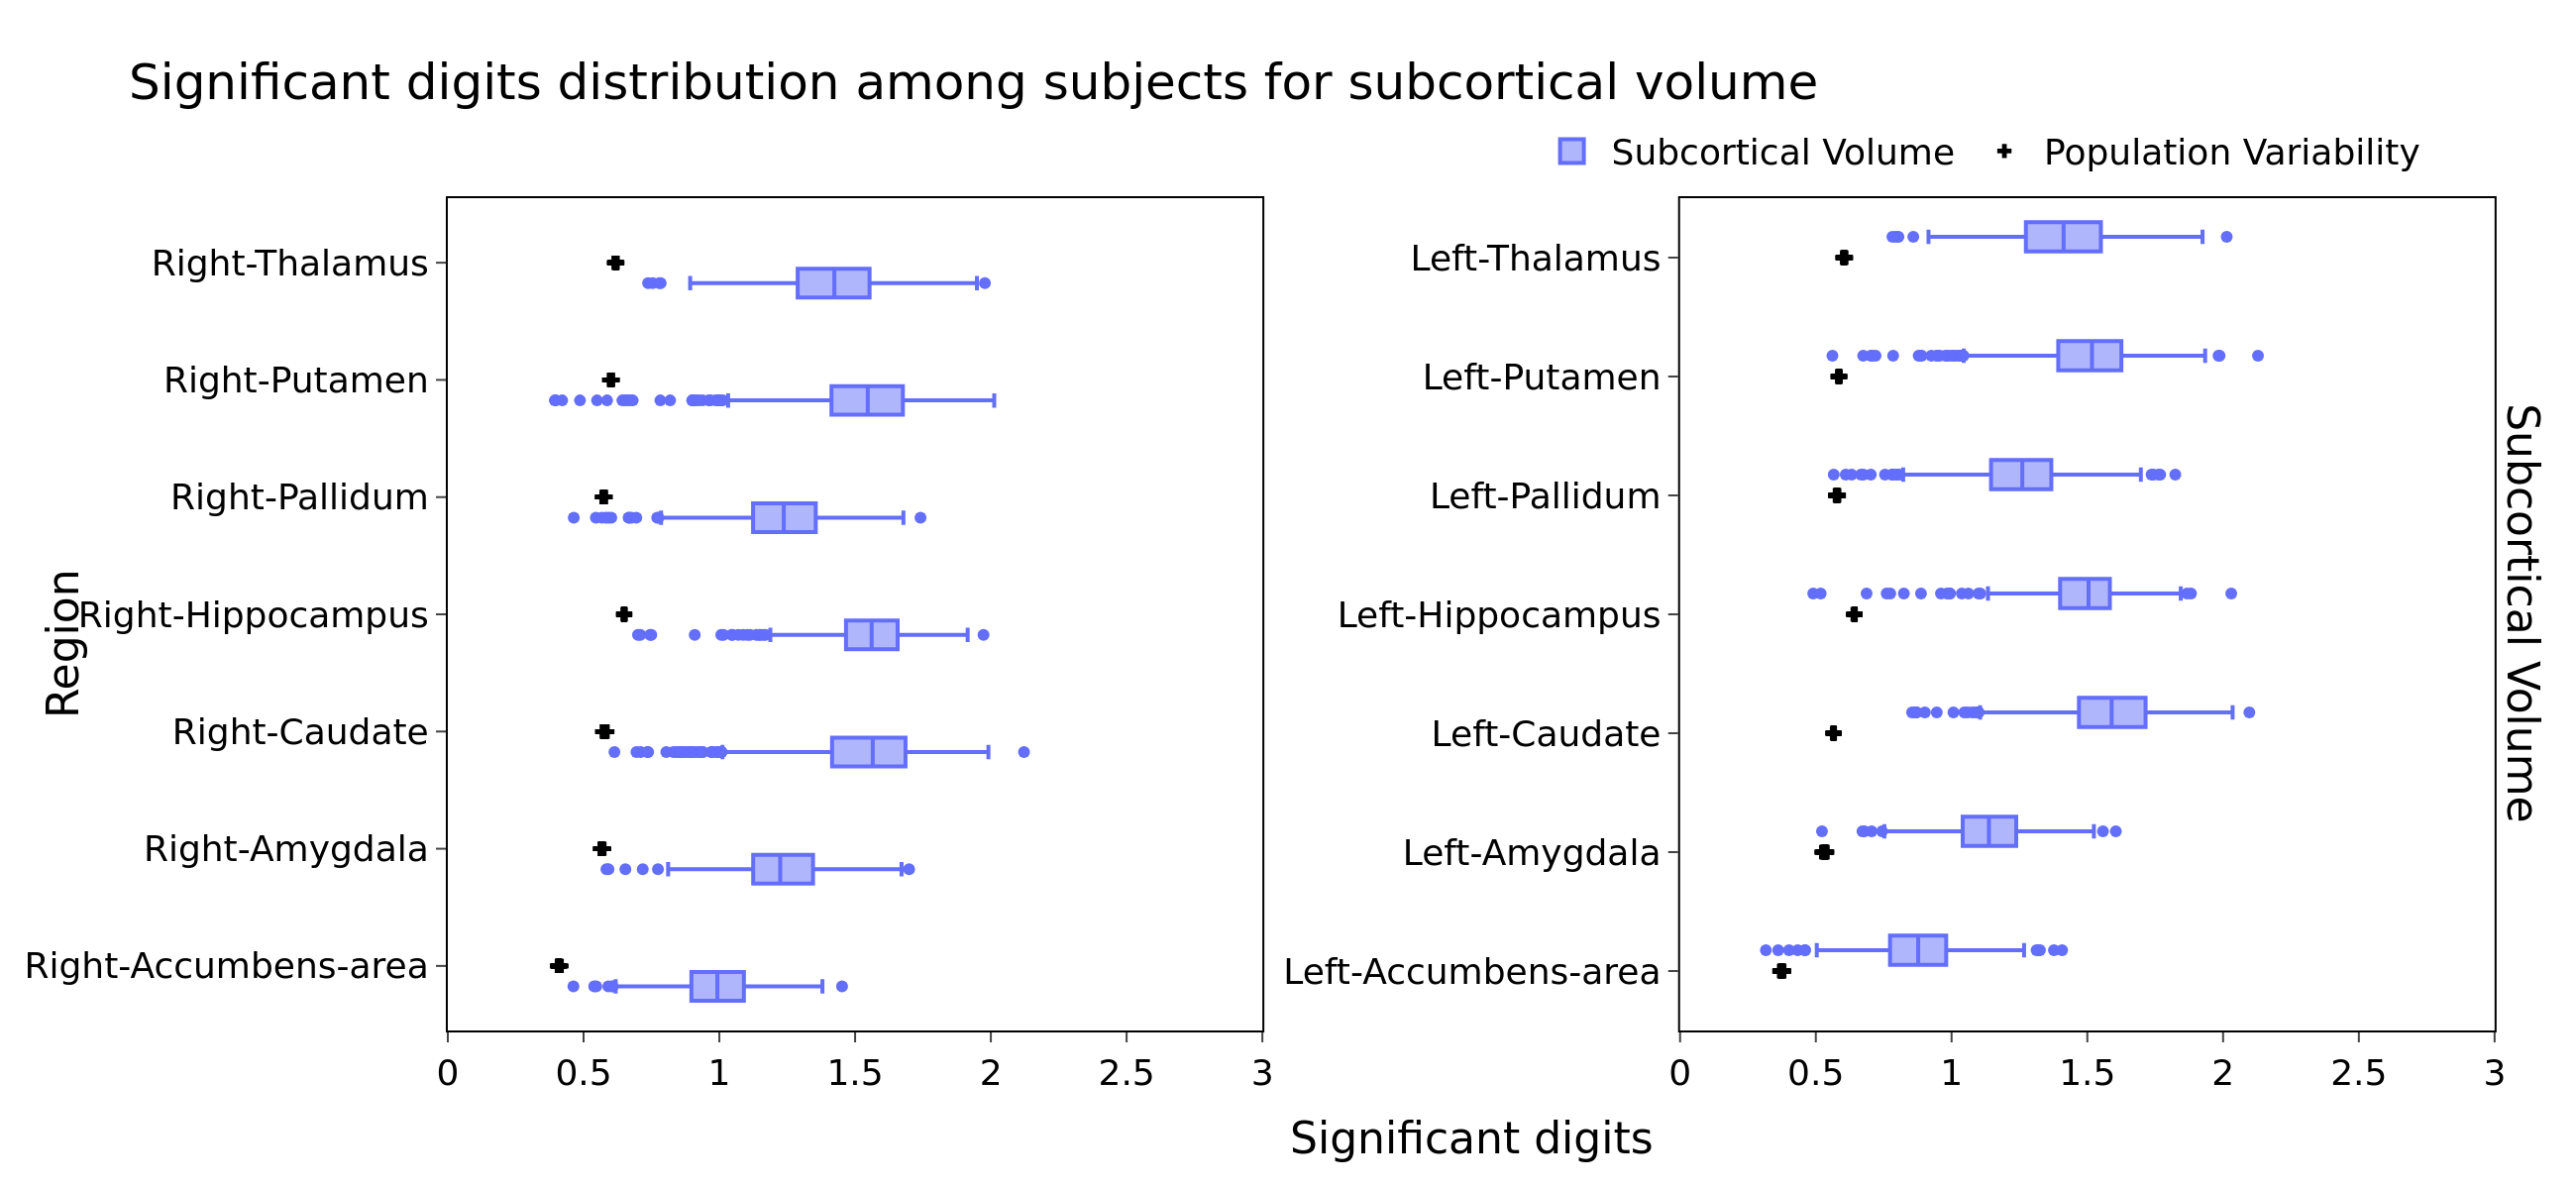

In [12]:
import plotly.colors as pc
from plotly.subplots import make_subplots


blue = pc.qualitative.Plotly[0]
red = pc.qualitative.Plotly[1]
green = pc.qualitative.Plotly[2]

color_map = {"Left": red, "Right": green}

fig = make_subplots(
    rows=1,
    cols=2,
    horizontal_spacing=0.20,
    vertical_spacing=0.0025,
    shared_xaxes=True,
    x_title="Significant digits",
    y_title="Region",
    row_titles=["Subcortical Volume"],
)

for i, metric in enumerate(["subcortical_volume"], start=1):
    sub_data_metric = sub_sd_data[metric]
    sub_data_metric["sig1"]["region"] = sub_data_metric["sig1"]["region"].astype(
        pd.CategoricalDtype(categories=subcortical_volume_labels, ordered=True)
    )
    sub_data_metric["sig2"]["region"] = sub_data_metric["sig2"]["region"].astype(
        pd.CategoricalDtype(categories=subcortical_volume_labels, ordered=True)
    )
    sub_data_metric["subvar1"]["region"] = sub_data_metric["subvar1"]["region"].astype(
        pd.CategoricalDtype(categories=subcortical_volume_labels, ordered=True)
    )
    sub_data_metric["subvar2"]["region"] = sub_data_metric["subvar2"]["region"].astype(
        pd.CategoricalDtype(categories=subcortical_volume_labels, ordered=True)
    )

    fig1 = px.box(sub_data_metric["sig1"], x="significant_digits", y="region")
    fig2 = px.box(sub_data_metric["sig2"], x="significant_digits", y="region")

    for data in fig1.data:
        data.showlegend = False
        data.legendgroup = "Subcortical Volume"
        data.name = "Subcortical Volume"
        fig.add_trace(data, row=i, col=1)

    for data in fig2.data:
        data.showlegend = False
        fig.add_trace(data, row=i, col=2)

    cross1 = px.scatter(
        sub_data_metric["subvar1"],
        x="significant_digits",
        y="region",
        color_discrete_sequence=["black"],
    )
    cross2 = px.scatter(
        sub_data_metric["subvar2"],
        x="significant_digits",
        y="region",
        color_discrete_sequence=["black"],
    )

    for data in cross1.data:
        data.showlegend = False
        data.legendgroup = "Population Variability"
        data.name = "Population Variability"
        data.marker.symbol = "cross"
        fig.add_trace(data, row=i, col=1)

    for data in cross2.data:
        data.showlegend = False
        data.marker.symbol = "cross"
        fig.add_trace(data, row=i, col=2)


fig.data[0].showlegend = True
fig.data[1].showlegend = False
fig.data[2].showlegend = True

fig.update_layout(
    boxmode="group",
    title="Significant digits distribution among subjects",
    legend=dict(
        title="",
        tracegroupgap=0,
        orientation="h",
        yanchor="top",
        y=1.10,
        xanchor="right",
        x=0.95,
        bgcolor="rgba(255, 255, 255, 0)",
    ),
    margin=dict(l=200, r=20, t=100, b=80),
    font=dict(size=22),
    paper_bgcolor="white",
    plot_bgcolor="white",
)

fig.update_xaxes(range=[0, 3])
fig.update_yaxes(
    title_font=dict(size=22),
    tickfont=dict(size=18),
)
fig.update_layout(font=dict(family="Helvetica, sans-serif", size=18, color="black"))
# significant digits
fig.layout.annotations[-2].yshift = -40
# region label
fig.layout.annotations[-1].xshift = -180
# y-labels
fig.layout.annotations[-1].yshift = -15

fig.update_xaxes(
    mirror=True, ticks="outside", showline=True, linewidth=1, linecolor="black"
)
fig.update_yaxes(
    mirror=True, ticks="outside", showline=True, linewidth=1, linecolor="black"
)

fig.update_annotations(
    font_size=22,
    font_family="Helvetica, sans-serif",
    font_color="black",
)

fig.update_layout(
    width=1300,
    height=500,
    title="Significant digits distribution among subjects for subcortical volume",
)
save_figure(
    fig,
    figures_dir / "significant_digits_subcortical_volume",
    width=1300,
    height=600,
    scale=2,
    formats=["pdf", "png"],
)
filename = figures_dir / "significant_digits_subcortical_volume"
print(f"Figure saved to: {anondir(filename)}")
display(Image(filename.with_suffix(".png")))